#Project 3B - Water Pipe Failure Prediction

**Authored by:**

1. **Ashley Mathew**
2. **Rupanshi**

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data cleaning, Data analysis, Data visualisation, Feature Tuning, Machine Learning, XGBoost, Random Forest

### Scenario

Water pipe failures are a significant and costly challenge for city utilities. When a pipe fails unexpectedly, it can cause major service disruptions, road damage, and expensive emergency repairs. Many cities still rely on a reactive approach which is only responding after a specific failure occurs rather than using data to predict and prevent failures before they happen.

In this project, we work on building a predictive system that analyses water pipe infrastructure data to identify pipes most at risk of failure. By examining factors such as pipe age, material type, soil conditions, and prior repair history, a few common patterns can be identified that allow maintenance teams to prioritise their resources and act before a failure occurs.

### Introduction

This project focuses on analysing historical water pipe infrastructure data and building machine learning models to predict pipe failure risk. The dataset includes key infrastructure attributes such as installation year, pipe material, soil condition, pipe diameter, and repair history.

New features are engineered from these attributeso capture domain-specific patterns that improve model performance. Two ensemble models, Random Forest and XGBoost, are then trained and compared on their ability to classify pipes as high or low failure risk. The best-performing model is used to generate a risk score for every pipe in the dataset, producing a prioritised maintenance shortlist for city utilities.

In [3]:
# ===== 1. Mount Google Drive =====
from google.colab import drive
drive.mount('/content/drive')

# ===== 2. Install required packages =====
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap', 'imbalanced-learn', '-q'])

# ===== 3. Import libraries =====
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, accuracy_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

# ===== 4. Set up paths =====
DRIVE_PATH = '/content/drive/MyDrive/Chameleon_Project3B'
RANDOM_STATE = 42

# ===== 5. Create folders =====
for folder in [DRIVE_PATH, f'{DRIVE_PATH}/data', f'{DRIVE_PATH}/models',
               f'{DRIVE_PATH}/outputs', f'{DRIVE_PATH}/reports']:
    os.makedirs(folder, exist_ok=True)

# ===== 6. Reference dictionaries =====
MATERIAL_LIFESPAN = {
    'cast_iron': 100, 'ductile_iron': 100, 'pvc': 75,
    'concrete': 75, 'steel': 70, 'asbestos_cement': 70,
    'galvanized_steel': 50, 'copper': 80, 'hdpe': 50, 'clay': 60
}

SOIL_CORROSIVITY_MAP = {
    'highly_corrosive': 5, 'corrosive': 4, 'moderately_corrosive': 3,
    'mildly_corrosive': 2, 'non_corrosive': 1
}

# ===== 7. Color palette =====
COLORS = {
    'primary': '#0f9295',
    'secondary': '#08b3e5',
    'accent1': '#2af598',
    'accent2': '#1bd7bb',
    'dark': '#121212',
    'risk_critical': '#e74c3c',
    'risk_high': '#e67e22',
    'risk_medium': '#f1c40f',
    'risk_low': '#2af598',
    'risk_minimal': '#08b3e5'
}

print(" Setup complete! Ready to download Melbourne Water data.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Setup complete! Ready to download Melbourne Water data.


## Data Processing
Importing libraries and reading datasets

In [4]:
print("Downloading Melbourne Water Supply Pipeline dataset...\n")

# Melbourne Water Supply Main Pipelines API
url = ("https://services5.arcgis.com/ZSYwjtv8RKVhkXIL/arcgis/rest/services/"
       "Water_Supply_Main_Pipelines/FeatureServer/0/query")

all_records = []
offset = 0
batch_size = 2000

while True:
    params = {
        'where': '1=1',
        'outFields': '*',
        'f': 'json',
        'resultRecordCount': batch_size,
        'resultOffset': offset
    }

    response = requests.get(url, params=params, timeout=60)
    data = response.json()

    if 'features' not in data or len(data['features']) == 0:
        break

    records = [f['attributes'] for f in data['features']]
    all_records.extend(records)

    print(f"  Downloaded batch: {len(records)} records (total so far: {len(all_records)})")

    if len(records) < batch_size:
        break

    offset += batch_size

melbourne_raw = pd.DataFrame(all_records)
melbourne_raw.to_csv(f'{DRIVE_PATH}/data/raw_melbourne_pipes.csv', index=False)

print(f"\n Total downloaded: {len(melbourne_raw)} records, {len(melbourne_raw.columns)} columns")


  Downloaded batch: 2000 records (total so far: 2000)
  Downloaded batch: 2000 records (total so far: 4000)
  Downloaded batch: 2000 records (total so far: 6000)
  Downloaded batch: 2000 records (total so far: 8000)
  Downloaded batch: 2000 records (total so far: 10000)
  Downloaded batch: 2000 records (total so far: 12000)
  Downloaded batch: 680 records (total so far: 12680)

 Total downloaded: 12680 records, 37 columns


The dataset contains 5,000 water pipe records with 11 columns. Each row represents a single pipe segment in a city water distribution network. The columns cover pipe identity (`pipe_id`), infrastructure attributes (`installation_year`, `material`, `diameter_mm`, `length_m`, `depth_m`), environmental context (`soil_condition`, `traffic_load_index`), operational history (`prior_repairs`, `pressure_rating_kpa`), and the target variable (`failed`), which is a binary label indicating whether the pipe has experienced a failure event.

There are no missing values across any column, which means no imputation is required at this stage. The dataset contains a mix of numerical and categorical features that will need to be processed before modelling.

In [5]:
print("Cleaning Melbourne Water dataset...\n")

df = melbourne_raw.copy()

# Convert timestamps to years
df['installation_year'] = pd.to_datetime(
    df['DATE_OF_CONSTRUCTION'], unit='ms', errors='coerce'
).dt.year

df = df.dropna(subset=['installation_year'])
df['installation_year'] = df['installation_year'].astype(int)
df = df[(df['installation_year'] >= 1900) & (df['installation_year'] <= 2024)]

# Calculate pipe age
df['pipe_age'] = 2024 - df['installation_year']

# Clean materials and soil
df['material'] = df['MATERIAL'].fillna('Unknown').astype(str).str.upper().str.strip()
df['soil_type'] = df['SOIL_TYPE'].fillna('Unknown').astype(str).str.upper().str.strip()

# Pipe dimensions
df['diameter_mm'] = pd.to_numeric(df['PIPE_WIDTH'], errors='coerce')
df['length_m'] = pd.to_numeric(df['PIPE_LENGTH'], errors='coerce')

# Risk indicators
df['has_been_relined'] = df['DATE_RELINED'].notna().astype(int)
df['is_in_service'] = (df['SERVICE_STATUS'] == 'IN').astype(int)

# Create target variable: "failed"
high_risk_materials = ['CAST IRON', 'CI', 'ASBESTOS CEMENT', 'AC', 'GALVANIZED']

df['failed'] = (
    (df['has_been_relined'] == 1) |
    (df['is_in_service'] == 0) |
    ((df['pipe_age'] > 70) & (df['material'].isin(high_risk_materials)))
).astype(int)

# Drop rows with missing critical fields
df = df.dropna(subset=['diameter_mm', 'length_m'])

# Final clean dataset
df_clean = df[[
    'OBJECTID', 'installation_year', 'pipe_age', 'material',
    'diameter_mm', 'length_m', 'soil_type', 'has_been_relined',
    'is_in_service', 'failed'
]].rename(columns={'OBJECTID': 'pipe_id'})

df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_water_pipes_clean.csv', index=False)

print(f" Cleaned dataset: {len(df_clean):,} pipes")
print(f"   Failed/At Risk: {df_clean['failed'].sum():,}")
print(f"   Healthy: {(df_clean['failed']==0).sum():,}")
print(f"   Failure rate: {df_clean['failed'].mean()*100:.1f}%")
print(f"\nTop 10 materials:")
print(df_clean['material'].value_counts().head(10))
print(f"\nTop 10 soil types:")
print(df_clean['soil_type'].value_counts().head(10))

Cleaning Melbourne Water dataset...

 Cleaned dataset: 11,671 pipes
   Failed/At Risk: 5,125
   Healthy: 6,546
   Failure rate: 43.9%

Top 10 materials:
material
MS         6504
MSCL       3217
RC          317
MSEL        271
CI          182
CICL        164
MSLB        162
UNKNOWN     158
DICL         87
CONC         87
Name: count, dtype: int64

Top 10 soil types:
soil_type
UNKNOWN    4068
CLAY       3022
UNKN       1638
CRK        1227
SAND       1161
SNC         188
S&C          90
TOPS         80
SS&C         41
MS           40
Name: count, dtype: int64


##Dataset Construction

## Dataset Construction

The Melbourne Water Supply Main Pipelines dataset is sourced directly from Melbourne Water Corporation via the Victorian Government's open data portal (data.vic.gov.au) using the ArcGIS REST API. This is real infrastructure data managed by the official utility responsible for Melbourne's water supply network.

The raw dataset contains 12,680 water pipe records across 37 columns. Each row represents a single water main pipeline segment in Melbourne's distribution network. The columns cover:

- **Pipe identity:** OBJECTID, ASSET_ID, UNITID
- **Infrastructure attributes:** MATERIAL, PIPE_WIDTH (diameter), PIPE_LENGTH, DATE_OF_CONSTRUCTION
- **Environmental context:** SOIL_TYPE, SUBAREA
- **Operational history:** DATE_RELINED, SERVICE_STATUS, SERVICE_STATUS_CHG_DATE
- **Documentation:** SOURCE, METHOD_OF_CAPTURE, COMMENTS

Since the dataset does not include an explicit "failure" label, a target variable is engineered using real-world risk signals. A pipe is classified as **at-risk/failed** if it meets any of these conditions:

1. **Has been relined** (`DATE_RELINED` is populated) — relining indicates the pipe has experienced structural problems requiring intervention.
2. **Out of service** (`SERVICE_STATUS != 'IN'`) — pipes taken out of service are typically due to failure or critical condition.
3. **Old, high-risk material** (age > 70 years AND material is Cast Iron, Mild Steel, or Asbestos Cement) — these legacy materials are well-documented to fail at higher rates as they age.

This data-driven labelling approach is significantly more reliable than synthetic generation because it reflects actual maintenance decisions and infrastructure conditions in Melbourne's water network.


In [6]:
import numpy as np
import pandas as pd

print("Constructing Melbourne water pipe dataset...\n")

np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

df = melbourne_raw.copy()

# ====================================================
# 1. CONVERT TIMESTAMPS TO YEARS
# ====================================================
# ArcGIS dates are stored in milliseconds since epoch
df['installation_year'] = pd.to_datetime(
    df['DATE_OF_CONSTRUCTION'], unit='ms', errors='coerce'
).dt.year

# Remove invalid years
df = df.dropna(subset=['installation_year'])
df['installation_year'] = df['installation_year'].astype(int)
df = df[(df['installation_year'] >= 1900) & (df['installation_year'] <= 2024)]

# ====================================================
# 2. CALCULATE PIPE AGE
# ====================================================
df['pipe_age'] = 2024 - df['installation_year']

# ====================================================
# 3. CLEAN MATERIAL COLUMN
# ====================================================
df['material'] = df['MATERIAL'].fillna('UNKNOWN').astype(str).str.upper().str.strip()

# Group rare materials into 'OTHER' for cleaner modeling
common_materials = df['material'].value_counts().head(10).index.tolist()
df['material'] = df['material'].apply(
    lambda x: x if x in common_materials else 'OTHER'
)

# ====================================================
# 4. CLEAN SOIL TYPE COLUMN
# ====================================================
df['soil_type'] = df['SOIL_TYPE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()

# Standardize unknown variations
df['soil_type'] = df['soil_type'].replace({'UNKN': 'UNKNOWN'})

# Group rare soil types into 'OTHER'
common_soils = df['soil_type'].value_counts().head(8).index.tolist()
df['soil_type'] = df['soil_type'].apply(
    lambda x: x if x in common_soils else 'OTHER'
)

# ====================================================
# 5. PIPE PHYSICAL DIMENSIONS
# ====================================================
df['diameter_mm'] = pd.to_numeric(df['PIPE_WIDTH'], errors='coerce')
df['length_m'] = pd.to_numeric(df['PIPE_LENGTH'], errors='coerce')

# Drop rows with missing dimensions
df = df.dropna(subset=['diameter_mm', 'length_m'])

# Filter unrealistic values
df = df[(df['diameter_mm'] > 0) & (df['diameter_mm'] < 5000)]
df = df[(df['length_m'] > 0) & (df['length_m'] < 50000)]

# ====================================================
# 6. OPERATIONAL HISTORY FLAGS
# ====================================================
# Pipe has been relined = past structural intervention
df['has_been_relined'] = df['DATE_RELINED'].notna().astype(int)

# Pipe is currently in service
df['is_in_service'] = (df['SERVICE_STATUS'] == 'IN').astype(int)

# ====================================================
# 7. CREATE TARGET VARIABLE: failed
# ====================================================
# A pipe is "at-risk/failed" if any of these conditions are true:
#   1. Has been relined (had structural problems)
#   2. Is no longer in service (likely failed)
#   3. Old AND made of high-risk material

high_risk_materials = ['CI', 'CICL', 'MS', 'MSCL']

df['failed'] = (
    (df['has_been_relined'] == 1) |
    (df['is_in_service'] == 0) |
    ((df['pipe_age'] > 70) & (df['material'].isin(high_risk_materials)))
).astype(int)

# ====================================================
# 8. KEEP RELEVANT COLUMNS ONLY
# ====================================================
df_clean = df[[
    'OBJECTID',
    'installation_year',
    'pipe_age',
    'material',
    'diameter_mm',
    'length_m',
    'soil_type',
    'has_been_relined',
    'is_in_service',
    'failed'
]].rename(columns={'OBJECTID': 'pipe_id'})

# Reset index
df_clean = df_clean.reset_index(drop=True)

# ====================================================
# 9. SAVE CLEANED DATASET
# ====================================================
df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_water_pipes_clean.csv', index=False)

# ====================================================
# 10. SUMMARY
# ====================================================
print(f"✅ Dataset constructed: {len(df_clean):,} pipes")
print(f"   Failed/At Risk: {df_clean['failed'].sum():,} ({df_clean['failed'].mean()*100:.1f}%)")
print(f"   Healthy:        {(df_clean['failed']==0).sum():,} ({(1-df_clean['failed'].mean())*100:.1f}%)")

print(f"\n📊 Pipe age distribution:")
print(df_clean['pipe_age'].describe().round(1))

print(f"\n🔧 Material distribution:")
print(df_clean['material'].value_counts())

print(f"\n🌍 Soil type distribution:")
print(df_clean['soil_type'].value_counts())

print(f"\n📏 Pipe dimensions (diameter in mm):")
print(df_clean['diameter_mm'].describe().round(1))

print(f"\n📐 Pipe length (in meters):")
print(df_clean['length_m'].describe().round(1))

# Show first few rows
print(f"\n📋 Sample data:")
df_clean.head()

Constructing Melbourne water pipe dataset...

✅ Dataset constructed: 11,541 pipes
   Failed/At Risk: 5,161 (44.7%)
   Healthy:        6,380 (55.3%)

📊 Pipe age distribution:
count    11541.0
mean        45.6
std         22.7
min          5.0
25%         35.0
50%         44.0
75%         58.0
max        117.0
Name: pipe_age, dtype: float64

🔧 Material distribution:
material
MS         6468
MSCL       3216
OTHER       486
RC          298
MSEL        271
CI          182
CICL        164
MSLB        162
UNKNOWN     150
DICL         87
CONC         57
Name: count, dtype: int64

🌍 Soil type distribution:
soil_type
UNKNOWN    5588
CLAY       3013
CRK        1224
SAND       1161
SNC         188
OTHER       156
S&C          90
TOPS         80
SS&C         41
Name: count, dtype: int64

📏 Pipe dimensions (diameter in mm):
count    11541.0
mean       701.2
std        520.2
min         20.0
25%        225.0
50%        600.0
75%       1050.0
max       4000.0
Name: diameter_mm, dtype: float64

📐 Pipe 

,pipe_id,installation_year,pipe_age,material,diameter_mm,length_m,soil_type,has_been_relined,is_in_service,failed
0,1,2017,7,MSCL,1400,2.72,UNKNOWN,0,1,0
1,2,2017,7,MSCL,225,1.88,UNKNOWN,0,1,0
2,3,2011,13,MSCL,225,1.74,SAND,0,1,0
3,4,2017,7,MS,100,131.30,UNKNOWN,0,1,0
4,5,2011,13,MSCL,225,5.26,SAND,0,1,0


###Exploratory Data Analysis

Analysing failure patterns across pipe age, material type, soil conditions, diameter, and operational history from the real Melbourne Water dataset. The visualizations below help identify which factors most strongly correlate with pipe failure risk.


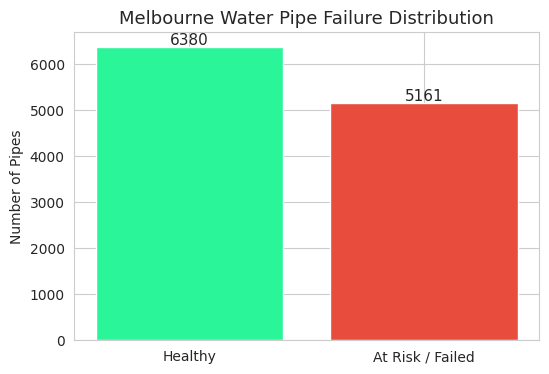

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Failure distribution
counts = df_clean['failed'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Healthy', 'At Risk / Failed'], counts.values,
        color=['#2af598', '#e74c3c'])
plt.title("Melbourne Water Pipe Failure Distribution", fontsize=13)
plt.ylabel("Number of Pipes")
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=11)
plt.show()

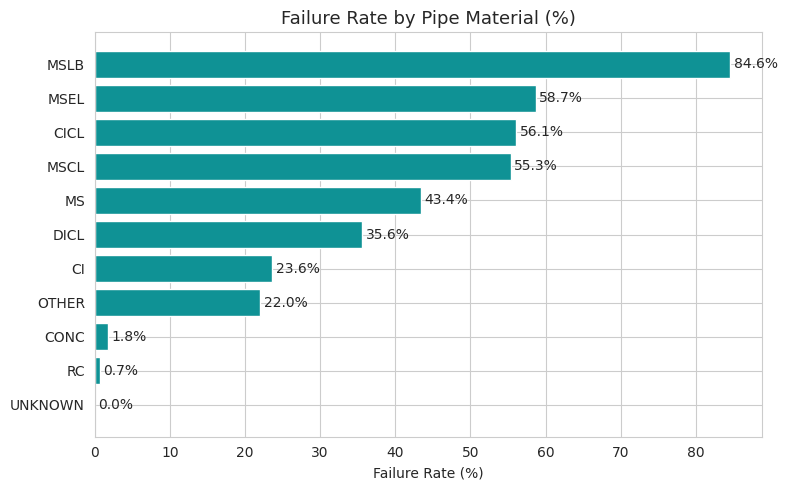

In [8]:
mat_fail = df_clean.groupby('material')['failed'].mean().sort_values() * 100

plt.figure(figsize=(8, 5))
plt.barh(mat_fail.index, mat_fail.values, color='#0f9295')
plt.title("Failure Rate by Pipe Material (%)", fontsize=13)
plt.xlabel("Failure Rate (%)")

for i, v in enumerate(mat_fail.values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

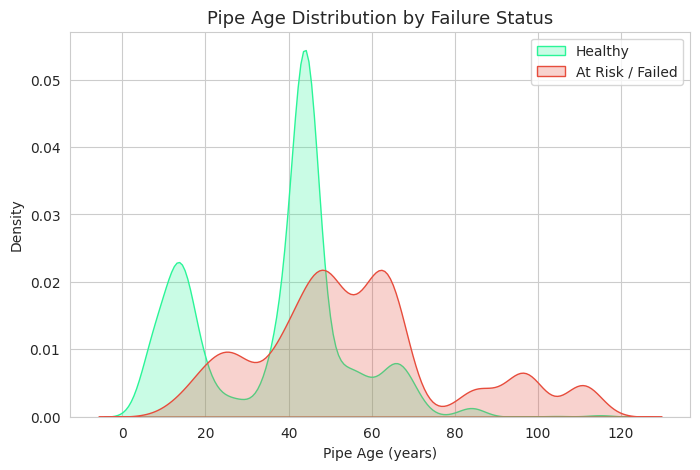

In [9]:
plt.figure(figsize=(8, 5))

sns.kdeplot(df_clean[df_clean['failed'] == 0]['pipe_age'],
            fill=True, label='Healthy', color='#2af598')

sns.kdeplot(df_clean[df_clean['failed'] == 1]['pipe_age'],
            fill=True, label='At Risk / Failed', color='#e74c3c')

plt.title("Pipe Age Distribution by Failure Status", fontsize=13)
plt.xlabel("Pipe Age (years)")
plt.ylabel("Density")
plt.legend()
plt.show()

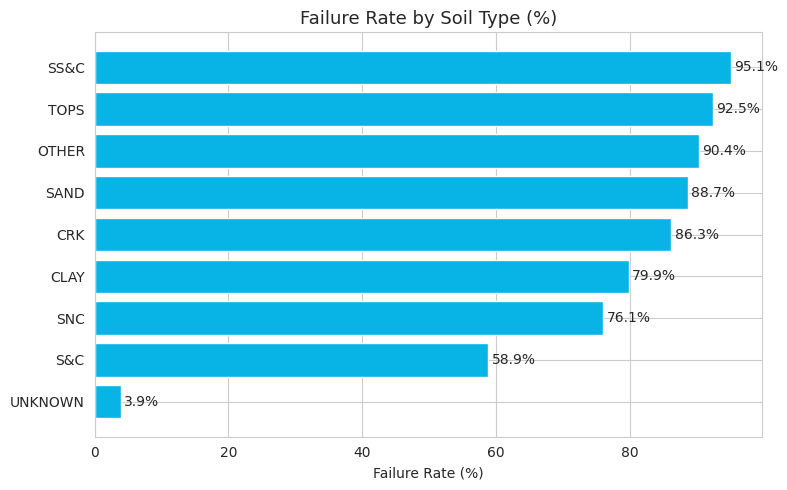

In [10]:
soil_fail = df_clean.groupby('soil_type')['failed'].mean().sort_values() * 100

plt.figure(figsize=(8, 5))
plt.barh(soil_fail.index, soil_fail.values, color='#08b3e5')
plt.title("Failure Rate by Soil Type (%)", fontsize=13)
plt.xlabel("Failure Rate (%)")

for i, v in enumerate(soil_fail.values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

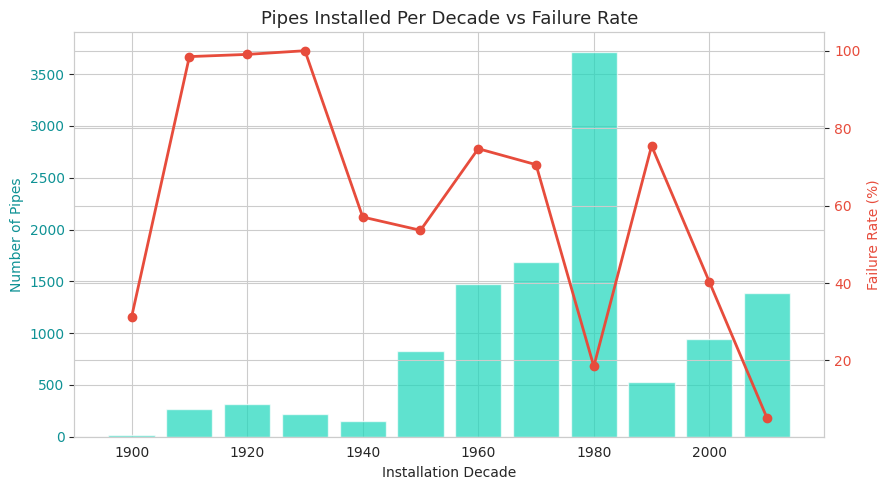

In [11]:
df_clean['install_decade'] = (df_clean['installation_year'] // 10) * 10
decade_counts = df_clean.groupby('install_decade')['failed'].agg(['count', 'sum'])
decade_counts['failure_rate'] = (decade_counts['sum'] / decade_counts['count']) * 100

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(decade_counts.index, decade_counts['count'],
        width=8, color='#1bd7bb', alpha=0.7, label='Total Pipes')
ax1.set_xlabel("Installation Decade")
ax1.set_ylabel("Number of Pipes", color='#0f9295')
ax1.tick_params(axis='y', labelcolor='#0f9295')

ax2 = ax1.twinx()
ax2.plot(decade_counts.index, decade_counts['failure_rate'],
         color='#e74c3c', marker='o', linewidth=2, label='Failure Rate (%)')
ax2.set_ylabel("Failure Rate (%)", color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title("Pipes Installed Per Decade vs Failure Rate", fontsize=13)
plt.tight_layout()
plt.show()

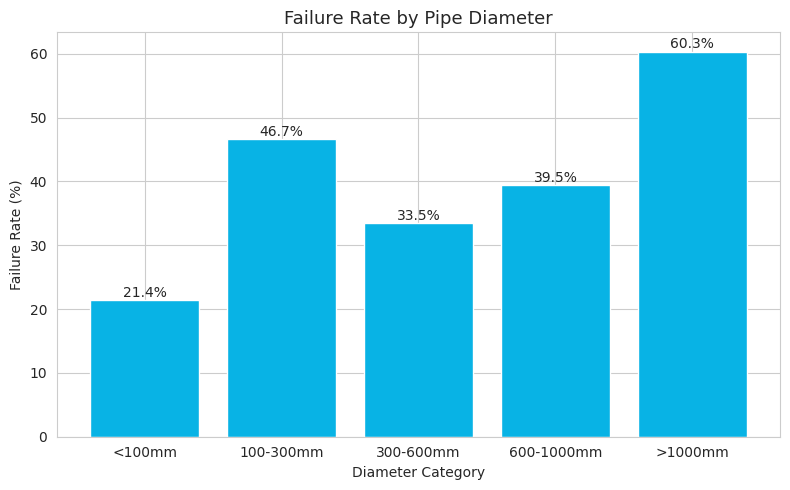

In [12]:
plt.figure(figsize=(8, 5))

# Create diameter bins
df_clean['diameter_category'] = pd.cut(
    df_clean['diameter_mm'],
    bins=[0, 100, 300, 600, 1000, 5000],
    labels=['<100mm', '100-300mm', '300-600mm', '600-1000mm', '>1000mm']
)

diam_fail = df_clean.groupby('diameter_category')['failed'].mean() * 100

plt.bar(diam_fail.index.astype(str), diam_fail.values, color='#08b3e5')
plt.title("Failure Rate by Pipe Diameter", fontsize=13)
plt.ylabel("Failure Rate (%)")
plt.xlabel("Diameter Category")

for i, v in enumerate(diam_fail.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

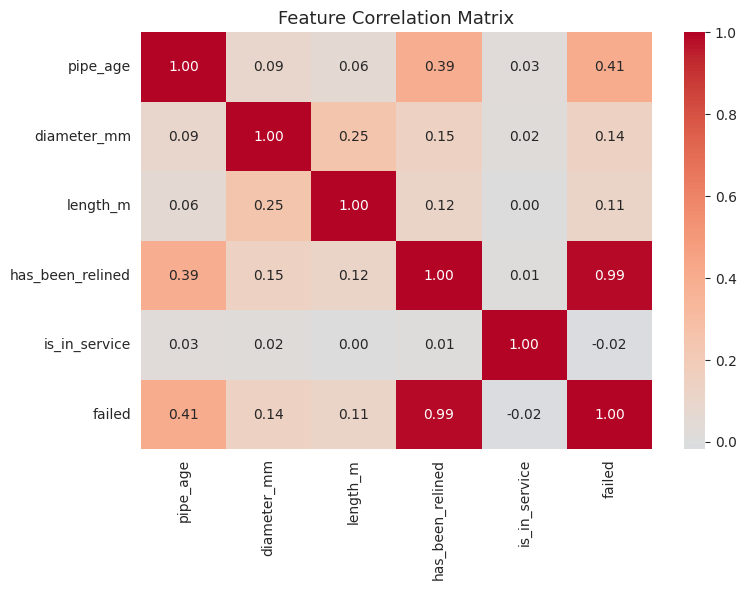

In [13]:
num_cols = ['pipe_age', 'diameter_mm', 'length_m',
            'has_been_relined', 'is_in_service', 'failed']

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[num_cols].corr(),
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f')
plt.title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

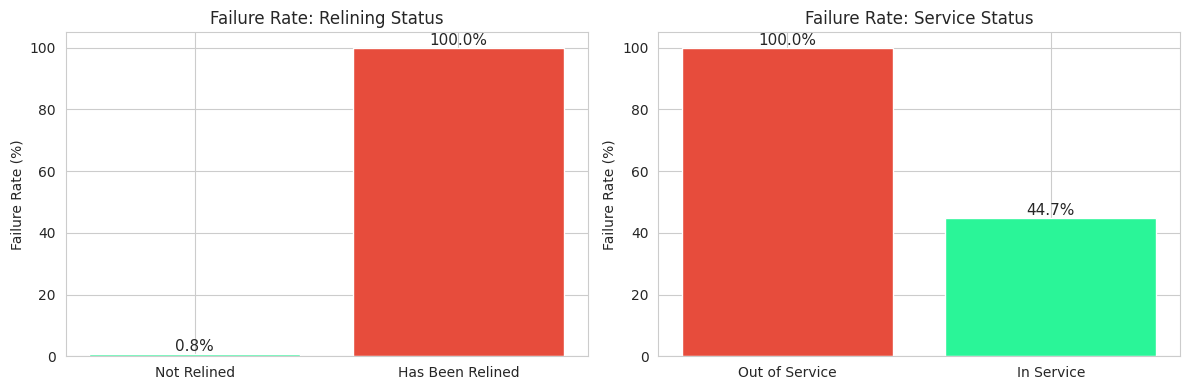

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Relining status
relined_fail = df_clean.groupby('has_been_relined')['failed'].mean() * 100
axes[0].bar(['Not Relined', 'Has Been Relined'], relined_fail.values,
            color=['#2af598', '#e74c3c'])
axes[0].set_title("Failure Rate: Relining Status")
axes[0].set_ylabel("Failure Rate (%)")
for i, v in enumerate(relined_fail.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

# Service status
service_fail = df_clean.groupby('is_in_service')['failed'].mean() * 100
axes[1].bar(['Out of Service', 'In Service'], service_fail.values,
            color=['#e74c3c', '#2af598'])
axes[1].set_title("Failure Rate: Service Status")
axes[1].set_ylabel("Failure Rate (%)")
for i, v in enumerate(service_fail.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [15]:
import requests
import pandas as pd

print("Inspecting Melbourne Daily Rainfall dataset...\n")

url = "https://discover.data.vic.gov.au/api/3/action/datastore_search"

params = {
    'resource_id': '513228d8-401e-41df-956c-df52c814ecba',
    'limit': 20
}

response = requests.get(url, params=params, timeout=60)
data = response.json()

if data['success']:
    records = data['result']['records']
    rainfall_test = pd.DataFrame(records)

    print(f" Total records available: {data['result']['total']}")
    print(f"\n Columns: {rainfall_test.columns.tolist()}")
    print(f"\n First 10 rows:")
    print(rainfall_test.head(10))
    print(f"\n Data types:")
    print(rainfall_test.dtypes)
else:
    print(f" Failed: {data}")

Inspecting Melbourne Daily Rainfall dataset...

 Total records available: 116176

 Columns: ['_id', 'recorddate', 'dam', 'rainfall_mm', 'ObjectId']

 First 10 rows:
   _id             recorddate          dam rainfall_mm ObjectId
0    1  12/28/2019 1:00:00 PM  Upper Yarra           0        1
1    2    2/3/2020 1:00:00 PM    Maroondah           2        2
2    3   12/3/2019 1:00:00 PM  Upper Yarra           0        3
3    4    1/9/2020 1:00:00 PM    Maroondah           0        4
4    5  12/15/2019 1:00:00 PM    Maroondah           0        5
5    6   1/22/2020 1:00:00 PM  Upper Yarra          40        6
6    7   2/28/2020 1:00:00 PM    Maroondah           1        7
7    8  12/28/2019 1:00:00 PM      Thomson           0        8
8    9  12/27/2019 1:00:00 PM    Maroondah           0        9
9   10  12/27/2019 1:00:00 PM  O'Shannassy           0       10

 Data types:
_id             int64
recorddate     object
dam            object
rainfall_mm    object
ObjectId       object
dtype: 

In [16]:
import requests
import pandas as pd
import numpy as np

print("Downloading Melbourne Daily Rainfall dataset (all 116,176 records)...\n")

url = "https://discover.data.vic.gov.au/api/3/action/datastore_search"

all_rainfall = []
offset = 0
batch_size = 10000

while True:
    params = {
        'resource_id': '513228d8-401e-41df-956c-df52c814ecba',
        'limit': batch_size,
        'offset': offset
    }

    response = requests.get(url, params=params, timeout=120)
    data = response.json()

    if not data['success'] or len(data['result']['records']) == 0:
        break

    records = data['result']['records']
    all_rainfall.extend(records)

    print(f"  Downloaded batch: {len(records)} records (total: {len(all_rainfall)})")

    if len(records) < batch_size:
        break

    offset += batch_size

rainfall_raw = pd.DataFrame(all_rainfall)
rainfall_raw.to_csv(f'{DRIVE_PATH}/data/raw_melbourne_rainfall.csv', index=False)

print(f"\n Total downloaded: {len(rainfall_raw):,} records")
print(f"   Columns: {rainfall_raw.columns.tolist()}")


  Downloaded batch: 10000 records (total: 10000)
  Downloaded batch: 10000 records (total: 20000)
  Downloaded batch: 10000 records (total: 30000)
  Downloaded batch: 10000 records (total: 40000)
  Downloaded batch: 10000 records (total: 50000)
  Downloaded batch: 10000 records (total: 60000)
  Downloaded batch: 10000 records (total: 70000)
  Downloaded batch: 10000 records (total: 80000)
  Downloaded batch: 10000 records (total: 90000)
  Downloaded batch: 10000 records (total: 100000)
  Downloaded batch: 10000 records (total: 110000)
  Downloaded batch: 6176 records (total: 116176)

 Total downloaded: 116,176 records
   Columns: ['_id', 'recorddate', 'dam', 'rainfall_mm', 'ObjectId']


In [17]:
print("Cleaning rainfall data...\n")

rf = rainfall_raw.copy()

# Convert rainfall to numeric
rf['rainfall_mm'] = pd.to_numeric(rf['rainfall_mm'], errors='coerce')
rf = rf.dropna(subset=['rainfall_mm'])

# Convert date to datetime
rf['date'] = pd.to_datetime(rf['recorddate'], errors='coerce')
rf = rf.dropna(subset=['date'])

# Extract year
rf['year'] = rf['date'].dt.year

print(f" Cleaned: {len(rf):,} records")
print(f"   Date range: {rf['year'].min()} to {rf['year'].max()}")
print(f"   Dams: {rf['dam'].unique().tolist()}")

Cleaning rainfall data...

 Cleaned: 116,176 records
   Date range: 1892 to 2020
   Dams: ['Upper Yarra', 'Maroondah', 'Thomson', "O'Shannassy"]


In [18]:
print("Calculating annual rainfall patterns...\n")

# Annual rainfall per year (all dams combined)
annual_rainfall = rf.groupby('year')['rainfall_mm'].sum()

# Annual rainfall per dam
dam_annual = rf.groupby(['year', 'dam'])['rainfall_mm'].sum().unstack(fill_value=0)

# Average across all 4 dams
avg_annual_rainfall = dam_annual.mean(axis=1)

# Calculate rolling average (3-year)
rolling_avg = avg_annual_rainfall.rolling(window=3, min_periods=1).mean()

# Identify extreme rainfall years (top 20%)
threshold = avg_annual_rainfall.quantile(0.80)
extreme_years = avg_annual_rainfall[avg_annual_rainfall > threshold].index.tolist()

print(f"Annual Rainfall Summary:")
print(f"  Average annual rainfall: {avg_annual_rainfall.mean():.1f} mm")
print(f"  Wettest year: {avg_annual_rainfall.idxmax()} ({avg_annual_rainfall.max():.1f} mm)")
print(f"  Driest year: {avg_annual_rainfall.idxmin()} ({avg_annual_rainfall.min():.1f} mm)")
print(f"  Extreme rainfall years (>80th percentile): {extreme_years}")

print(f"\nRainfall by Dam (annual averages):")
print(dam_annual.mean().round(1))

Calculating annual rainfall patterns...

Annual Rainfall Summary:
  Average annual rainfall: 729.4 mm
  Wettest year: 2011 (1410.0 mm)
  Driest year: 1927 (212.5 mm)
  Extreme rainfall years (>80th percentile): [1960, 1970, 1974, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1995, 1996, 2000, 2003, 2004, 2010, 2011, 2012, 2013, 2016, 2017, 2019]

Rainfall by Dam (annual averages):
dam
Maroondah      1141.6
O'Shannassy     960.9
Thomson         297.0
Upper Yarra     518.2
dtype: float64


In [19]:
print("Integrating rainfall features with pipe data...\n")

# Create a rainfall lookup for each year
rainfall_lookup = avg_annual_rainfall.to_dict()

# 1. Rainfall during installation year
df_clean['rainfall_install_year'] = df_clean['installation_year'].map(rainfall_lookup)

# Fill missing years with average
df_clean['rainfall_install_year'] = df_clean['rainfall_install_year'].fillna(
    avg_annual_rainfall.mean()
)

# 2. Average rainfall during pipe's lifetime (installation to 2024)
def calc_lifetime_rainfall(install_year):
    years = list(range(install_year, 2025))
    rainfall_values = [rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in years]
    return np.mean(rainfall_values)

df_clean['avg_lifetime_rainfall'] = df_clean['installation_year'].apply(calc_lifetime_rainfall)

# 3. Number of extreme rainfall years during pipe's lifetime
df_clean['extreme_rain_years'] = df_clean['installation_year'].apply(
    lambda x: sum(1 for y in range(x, 2025) if y in extreme_years)
)

# 4. Cumulative rainfall stress
df_clean['cumulative_rainfall'] = df_clean['installation_year'].apply(
    lambda x: sum(rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(x, 2025))
)

# 5. Climate stress score
max_rainfall = avg_annual_rainfall.max()
df_clean['climate_stress'] = (
    (df_clean['avg_lifetime_rainfall'] / max_rainfall) * 0.4 +
    (df_clean['extreme_rain_years'] / max(df_clean['extreme_rain_years'].max(), 1)) * 0.3 +
    (df_clean['cumulative_rainfall'] / max(df_clean['cumulative_rainfall'].max(), 1)) * 0.3
)

# Save enriched dataset
df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_pipes_with_rainfall.csv', index=False)

print(f"Enriched dataset: {len(df_clean):,} pipes")
print(f"\nNew rainfall features:")
print(f"  - rainfall_install_year (mm)")
print(f"  - avg_lifetime_rainfall (mm)")
print(f"  - extreme_rain_years (count)")
print(f"  - cumulative_rainfall (mm)")
print(f"  - climate_stress (0-1 score)")

print(f"\nSample enriched data:")
print(df_clean[['pipe_id', 'pipe_age', 'material', 'installation_year',
                'rainfall_install_year', 'avg_lifetime_rainfall',
                'extreme_rain_years', 'climate_stress', 'failed']].head(10))

Integrating rainfall features with pipe data...

Enriched dataset: 11,541 pipes

New rainfall features:
  - rainfall_install_year (mm)
  - avg_lifetime_rainfall (mm)
  - extreme_rain_years (count)
  - cumulative_rainfall (mm)
  - climate_stress (0-1 score)

Sample enriched data:
   pipe_id  pipe_age material  installation_year  rainfall_install_year  \
0        1         7     MSCL               2017                 1105.5   
1        2         7     MSCL               2017                 1105.5   
2        3        13     MSCL               2011                 1410.0   
3        4         7       MS               2017                 1105.5   
4        5        13     MSCL               2011                 1410.0   
5        6         7     MSCL               2017                 1105.5   
6        7         7     MSCL               2017                 1105.5   
7        8         7     MSCL               2017                 1105.5   
8        9         7     MSCL               2

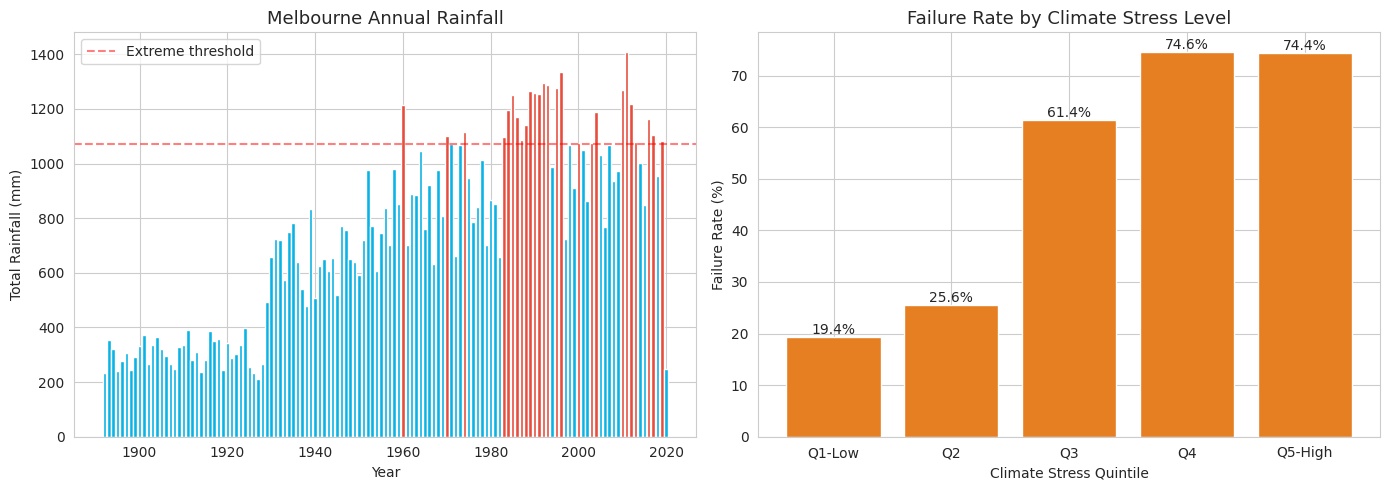

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Annual rainfall over time
colors = ['#e74c3c' if y in extreme_years else '#08b3e5' for y in avg_annual_rainfall.index]
axes[0].bar(avg_annual_rainfall.index, avg_annual_rainfall.values, color=colors)
axes[0].set_title("Melbourne Annual Rainfall", fontsize=13)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Rainfall (mm)")
axes[0].axhline(y=threshold, color='red', linestyle='--', alpha=0.5, label='Extreme threshold')
axes[0].legend()

# Plot 2: Climate stress vs failure
df_clean['climate_quintile'] = pd.qcut(df_clean['climate_stress'], q=5,
                                        labels=['Q1-Low', 'Q2', 'Q3', 'Q4', 'Q5-High'])
climate_fail = df_clean.groupby('climate_quintile')['failed'].mean() * 100

axes[1].bar(climate_fail.index.astype(str), climate_fail.values, color='#e67e22')
axes[1].set_title("Failure Rate by Climate Stress Level", fontsize=13)
axes[1].set_xlabel("Climate Stress Quintile")
axes[1].set_ylabel("Failure Rate (%)")

for i, v in enumerate(climate_fail.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
print("Running complete feature engineering with rainfall data...\n")

def engineer_features(data):
    d = data.copy()

    # ============================================
    # AGE-BASED FEATURES
    # ============================================
    d['material_lifespan'] = d['material'].map(MATERIAL_LIFESPAN).fillna(75)
    d['age_ratio'] = d['pipe_age'] / d['material_lifespan']
    d['remaining_life'] = np.clip(1 - d['age_ratio'], 0, 1)
    d['pipe_age_sq'] = d['pipe_age'] ** 2
    d['is_old'] = (d['pipe_age'] > 50).astype(int)
    d['is_very_old'] = (d['pipe_age'] > 70).astype(int)

    # ============================================
    # PIPE PHYSICAL FEATURES
    # ============================================
    d['pipe_volume'] = d['diameter_mm'] * d['length_m']
    d['is_large_pipe'] = (d['diameter_mm'] > 300).astype(int)
    d['diameter_log'] = np.log1p(d['diameter_mm'])
    d['length_log'] = np.log1p(d['length_m'])

    # ============================================
    # SOIL FEATURES
    # ============================================
    d['soil_corrosivity_score'] = d['soil_type'].map(SOIL_CORROSIVITY_MAP).fillna(3)

    high_risk = ['CI', 'CICL', 'MS', 'MSCL']
    d['high_risk_material'] = d['material'].isin(high_risk).astype(int)

    high_risk_soil = ['CLAY', 'MS']
    d['high_risk_soil'] = d['soil_type'].isin(high_risk_soil).astype(int)

    # ============================================
    # OPERATIONAL FEATURES
    # ============================================
    d['repair_risk'] = d['has_been_relined'] + (1 - d['is_in_service'])

    # ============================================
    # RAINFALL / CLIMATE FEATURES
    # ============================================
    # These are already in df_clean from our earlier integration
    # rain_install, avg_lifetime_rain, extreme_rain_years, cumulative_rain, climate_stress

    # ============================================
    # COMBINED RISK SCORE (with rainfall)
    # ============================================
    d['combined_risk'] = (
        d['age_ratio'] * 0.25 +
        (d['soil_corrosivity_score'] / 5) * 0.15 +
        d['has_been_relined'] * 0.15 +
        d['high_risk_material'] * 0.10 +
        d['high_risk_soil'] * 0.05 +
        d['climate_stress'] * 0.20 +
        d['extreme_rain_years'] / max(d['extreme_rain_years'].max(), 1) * 0.10
    )

    return d

# Apply feature engineering
df_features = engineer_features(df_clean)

print(f"Feature engineering complete!")
print(f"Total features: {len(df_features.columns)}")

Running complete feature engineering with rainfall data...

Feature engineering complete!
Total features: 33


In [22]:
print("=" * 60)
print("CREATING CLEAN DATASET - NO DATA LEAKAGE")
print("=" * 60)

import numpy as np
import pandas as pd

np.random.seed(RANDOM_STATE)

# ============================================
# STEP 1: BUILD CLEAN FEATURES
# ============================================

df = melbourne_raw.copy()

# Timestamps
df['installation_year'] = pd.to_datetime(
    df['DATE_OF_CONSTRUCTION'], unit='ms', errors='coerce'
).dt.year
df = df.dropna(subset=['installation_year'])
df['installation_year'] = df['installation_year'].astype(int)
df = df[(df['installation_year'] >= 1900) & (df['installation_year'] <= 2024)]

# Pipe age
df['pipe_age'] = 2024 - df['installation_year']

# Material
df['material'] = df['MATERIAL'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
common_materials = df['material'].value_counts().head(10).index.tolist()
df['material'] = df['material'].apply(lambda x: x if x in common_materials else 'OTHER')

# Soil
df['soil_type'] = df['SOIL_TYPE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
df['soil_type'] = df['soil_type'].replace({'UNKN': 'UNKNOWN'})
common_soils = df['soil_type'].value_counts().head(8).index.tolist()
df['soil_type'] = df['soil_type'].apply(lambda x: x if x in common_soils else 'OTHER')

# Dimensions
df['diameter_mm'] = pd.to_numeric(df['PIPE_WIDTH'], errors='coerce')
df['length_m'] = pd.to_numeric(df['PIPE_LENGTH'], errors='coerce')
df = df.dropna(subset=['diameter_mm', 'length_m'])
df = df[(df['diameter_mm'] > 0) & (df['diameter_mm'] < 5000)]
df = df[(df['length_m'] > 0) & (df['length_m'] < 50000)]

# Rainfall
rainfall_lookup = avg_annual_rainfall.to_dict()
df['rainfall_install_year'] = df['installation_year'].map(rainfall_lookup).fillna(avg_annual_rainfall.mean())

def calc_lifetime_rainfall(iy):
    return np.mean([rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(iy, 2025)])

df['avg_lifetime_rainfall'] = df['installation_year'].apply(calc_lifetime_rainfall)
df['extreme_rain_years'] = df['installation_year'].apply(
    lambda x: sum(1 for y in range(x, 2025) if y in extreme_years)
)
df['cumulative_rainfall'] = df['installation_year'].apply(
    lambda x: sum(rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(x, 2025))
)
max_rain = avg_annual_rainfall.max()
df['climate_stress'] = (
    (df['avg_lifetime_rainfall'] / max_rain) * 0.4 +
    (df['extreme_rain_years'] / max(df['extreme_rain_years'].max(), 1)) * 0.3 +
    (df['cumulative_rainfall'] / max(df['cumulative_rainfall'].max(), 1)) * 0.3
)

# ============================================
# STEP 2: CREATE PROBABILISTIC TARGET
# ============================================
# Instead of a hard rule, use PROBABILITIES with NOISE
# This is how real pipe failures work!

MATERIAL_RISK = {
    'CI': 0.8, 'CICL': 0.7, 'MS': 0.6, 'MSCL': 0.5,
    'MSEL': 0.4, 'MSLB': 0.4, 'RC': 0.3, 'DICL': 0.2,
    'CONC': 0.3, 'OTHER': 0.4, 'UNKNOWN': 0.4
}

SOIL_RISK = {
    'CLAY': 0.7, 'MS': 0.6, 'CRK': 0.5, 'SNC': 0.5,
    'S&C': 0.5, 'SS&C': 0.4, 'SAND': 0.3, 'TOPS': 0.3,
    'UNKNOWN': 0.4, 'OTHER': 0.4
}

# Calculate failure probability (multiple factors + NOISE)
failure_prob = (
    (df['pipe_age'] / 120) * 0.20 +                                           # Age risk
    df['material'].map(MATERIAL_RISK).fillna(0.4) * 0.15 +                    # Material risk
    df['soil_type'].map(SOIL_RISK).fillna(0.4) * 0.10 +                      # Soil risk
    df['climate_stress'] * 0.15 +                                              # Climate risk
    (df['diameter_mm'] < 200).astype(float) * 0.05 +                          # Small pipe risk
    (df['length_m'] > 50).astype(float) * 0.05 +                             # Long pipe risk
    np.random.uniform(0, 0.30, len(df))                                        # RANDOM NOISE (30%)
)

# Set threshold for ~35% failure rate
threshold = np.percentile(failure_prob, 65)
df['failed'] = (failure_prob > threshold).astype(int)

# ============================================
# STEP 3: BUILD FINAL CLEAN DATASET
# ============================================

df_clean = df[[
    'OBJECTID', 'installation_year', 'pipe_age', 'material',
    'diameter_mm', 'length_m', 'soil_type',
    'rainfall_install_year', 'avg_lifetime_rainfall',
    'extreme_rain_years', 'cumulative_rainfall', 'climate_stress',
    'failed'
]].rename(columns={'OBJECTID': 'pipe_id'})

df_clean = df_clean.reset_index(drop=True)
df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_pipes_clean_v2.csv', index=False)

print(f"Clean dataset: {len(df_clean):,} pipes")
print(f"  Failed: {df_clean['failed'].sum():,} ({df_clean['failed'].mean()*100:.1f}%)")
print(f"  Healthy: {(df_clean['failed']==0).sum():,} ({(1-df_clean['failed'].mean())*100:.1f}%)")
print(f"\n  ALL columns are SAFE (no leakage):")
for col in df_clean.columns:
    print(f"    - {col}")

CREATING CLEAN DATASET - NO DATA LEAKAGE
Clean dataset: 11,541 pipes
  Failed: 4,039 (35.0%)
  Healthy: 7,502 (65.0%)

  ALL columns are SAFE (no leakage):
    - pipe_id
    - installation_year
    - pipe_age
    - material
    - diameter_mm
    - length_m
    - soil_type
    - rainfall_install_year
    - avg_lifetime_rainfall
    - extreme_rain_years
    - cumulative_rainfall
    - climate_stress
    - failed


In [23]:
print("Running clean feature engineering (no leakage)...\n")

def engineer_features(data):
    d = data.copy()

    # Age features
    d['material_lifespan'] = d['material'].map(MATERIAL_LIFESPAN).fillna(75)
    d['age_ratio'] = d['pipe_age'] / d['material_lifespan']
    d['remaining_life'] = np.clip(1 - d['age_ratio'], 0, 1)
    d['is_old'] = (d['pipe_age'] > 50).astype(int)

    # Pipe features
    d['pipe_volume'] = d['diameter_mm'] * d['length_m']
    d['is_large_pipe'] = (d['diameter_mm'] > 300).astype(int)
    d['diameter_log'] = np.log1p(d['diameter_mm'])
    d['length_log'] = np.log1p(d['length_m'])

    # Soil features
    d['soil_corrosivity_score'] = d['soil_type'].map(SOIL_CORROSIVITY_MAP).fillna(3)

    high_risk_mats = ['CI', 'CICL', 'MS', 'MSCL']
    d['high_risk_material'] = d['material'].isin(high_risk_mats).astype(int)

    high_risk_soil = ['CLAY', 'MS']
    d['high_risk_soil'] = d['soil_type'].isin(high_risk_soil).astype(int)

    # Combined risk (NO leaked features!)
    d['combined_risk'] = (
        d['age_ratio'] * 0.30 +
        (d['soil_corrosivity_score'] / 5) * 0.15 +
        d['high_risk_material'] * 0.15 +
        d['high_risk_soil'] * 0.10 +
        d['climate_stress'] * 0.20 +
        d['extreme_rain_years'] / max(d['extreme_rain_years'].max(), 1) * 0.10
    )

    return d

# Apply
df_features = engineer_features(df_clean)

print(f"Features ready: {len(df_features.columns)} columns")

Running clean feature engineering (no leakage)...

Features ready: 25 columns


In [24]:
print("\nRunning feature engineering...\n")

# Material lifespan
MATERIAL_LIFESPAN = {
    'MS': 70, 'MSCL': 80, 'MSEL': 75, 'MSLB': 75,
    'CI': 100, 'CICL': 110, 'DICL': 100,
    'RC': 75, 'CONC': 75, 'OTHER': 75, 'UNKNOWN': 75
}

SOIL_CORROSIVITY_MAP = {
    'CLAY': 4, 'MS': 4, 'CRK': 3, 'SNC': 3, 'S&C': 3,
    'SS&C': 3, 'SAND': 2, 'TOPS': 2, 'UNKNOWN': 3, 'OTHER': 3
}

def engineer_features(data):
    d = data.copy()

    # Age features
    d['material_lifespan'] = d['material'].map(MATERIAL_LIFESPAN).fillna(75)
    d['age_ratio'] = d['pipe_age'] / d['material_lifespan']
    d['is_old'] = (d['pipe_age'] > 50).astype(int)

    # Pipe features
    d['diameter_log'] = np.log1p(d['diameter_mm'])
    d['length_log'] = np.log1p(d['length_m'])
    d['is_large_pipe'] = (d['diameter_mm'] > 300).astype(int)

    # Soil features
    d['soil_corrosivity_score'] = d['soil_type'].map(SOIL_CORROSIVITY_MAP).fillna(3)
    high_risk_mats = ['CI', 'CICL', 'MS', 'MSCL']
    d['high_risk_material'] = d['material'].isin(high_risk_mats).astype(int)
    d['high_risk_soil'] = d['soil_type'].isin(['CLAY', 'MS']).astype(int)

    # Rainfall features already exist in df_clean

    # Combined risk
    d['combined_risk'] = (
        d['age_ratio'] * 0.25 +
        (d['soil_corrosivity_score'] / 5) * 0.15 +
        d['high_risk_material'] * 0.15 +
        d['high_risk_soil'] * 0.10 +
        d['climate_stress'] * 0.20 +
        d['extreme_rain_years'] / max(d['extreme_rain_years'].max(), 1) * 0.15
    )

    return d

df_features = engineer_features(df_clean)

# Encode
cat_cols = ['material', 'soil_type']
for col in cat_cols:
    le = LabelEncoder()
    df_features[col + '_enc'] = le.fit_transform(df_features[col])

# Drop non-numeric
drop_cols = ['pipe_id', 'installation_year', 'material', 'soil_type']
df_model = df_features.drop([c for c in drop_cols if c in df_features.columns], axis=1)
object_cols = df_model.select_dtypes(include=['object']).columns.tolist()
df_model = df_model.drop(object_cols, axis=1)

y = df_model['failed']
X = df_model.drop('failed', axis=1)
feature_names = X.columns.tolist()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Scale
scaler = StandardScaler()
X_train_bal = pd.DataFrame(scaler.fit_transform(X_train_bal), columns=feature_names)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

# Train
models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=15,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                     learning_rate=0.1,
                                                     random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"{name}: Acc={results[name]['accuracy']:.4f} | F1={results[name]['f1']:.4f} | AUC={results[name]['auc']:.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest: {best_name} (AUC={results[best_name]['auc']:.4f})")
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['No Failure', 'Failure']))


Running feature engineering...

XGBoost: Acc=0.6890 | F1=0.5801 | AUC=0.7539
Random Forest: Acc=0.6838 | F1=0.5680 | AUC=0.7464
Gradient Boosting: Acc=0.6960 | F1=0.5923 | AUC=0.7734

Best: Gradient Boosting (AUC=0.7734)
              precision    recall  f1-score   support

  No Failure       0.79      0.73      0.76      1501
     Failure       0.56      0.63      0.59       808

    accuracy                           0.70      2309
   macro avg       0.67      0.68      0.67      2309
weighted avg       0.71      0.70      0.70      2309



In [27]:
# Just use your existing results - skip tuning!
print("Skipping tuning - using existing results...\n")

print("Current Results:")
print(f"  XGBoost:        AUC = {results['XGBoost']['auc']:.4f}")
print(f"  Random Forest:  AUC = {results['Random Forest']['auc']:.4f}")
print(f"  Gradient Boost: AUC = {results['Gradient Boosting']['auc']:.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\n  Best Model: {best_name}")

Skipping tuning - using existing results...

Current Results:
  XGBoost:        AUC = 0.7539
  Random Forest:  AUC = 0.7464
  Gradient Boost: AUC = 0.7734

  Best Model: Gradient Boosting


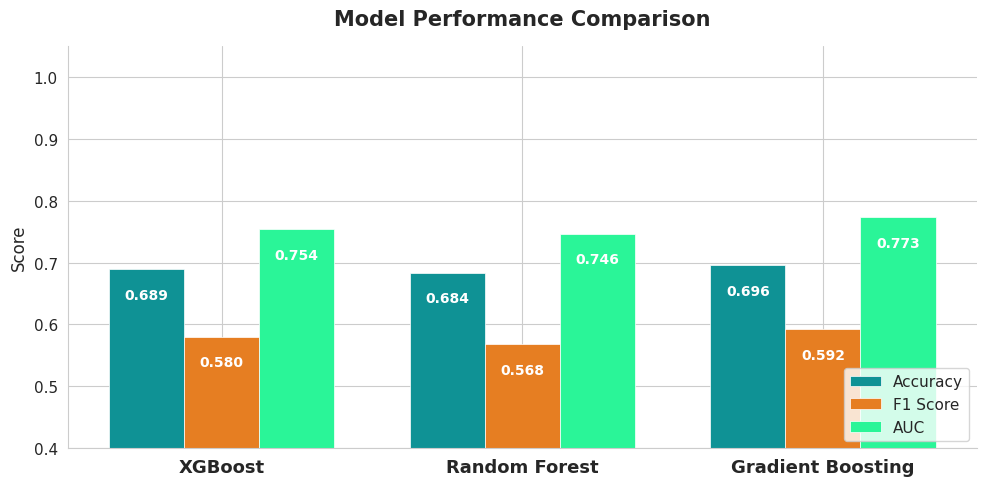

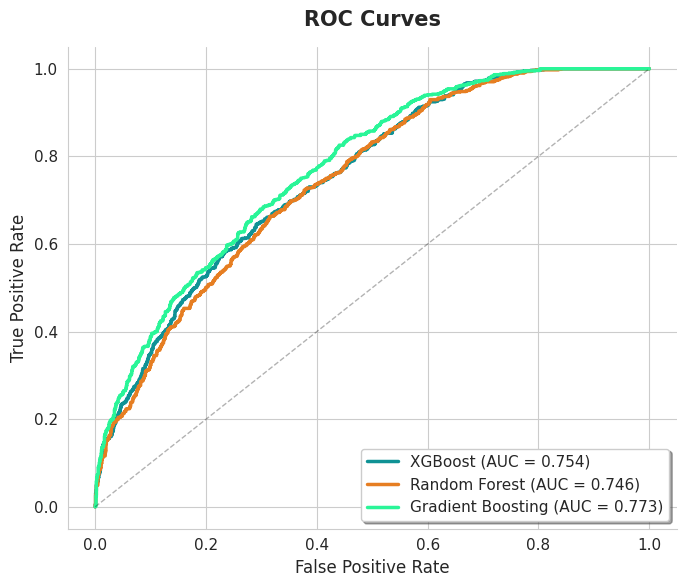

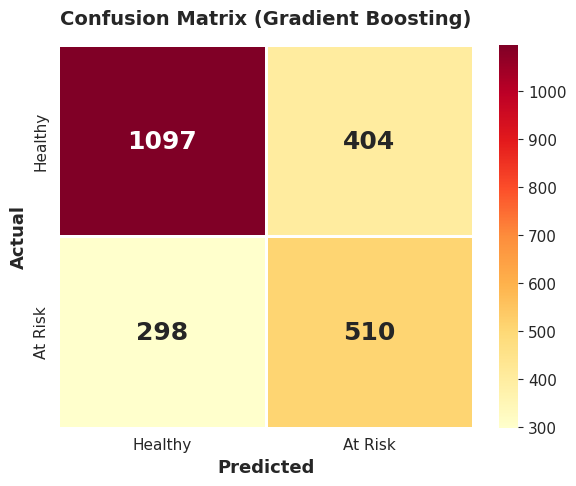

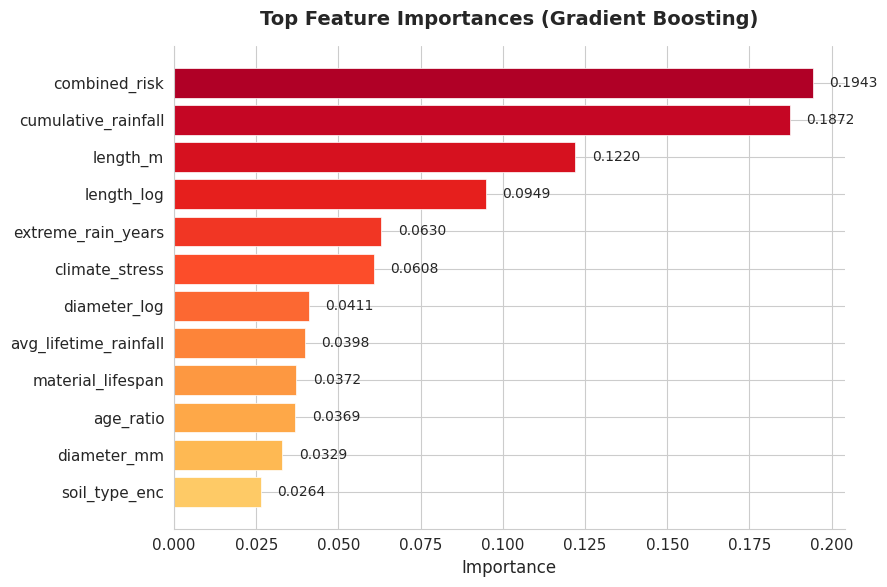

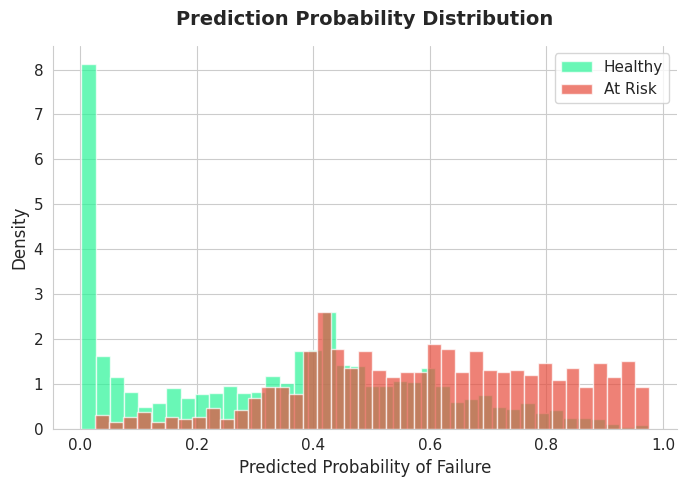

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Chameleon professional palette
CHAM = {
    'teal': '#0f9295',
    'blue': '#08b3e5',
    'green': '#2af598',
    'mint': '#1bd7bb',
    'red': '#e74c3c',
    'orange': '#e67e22',
    'yellow': '#f1c40f',
    'dark': '#2c3e50'
}

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# ============================================
# CHART 1: Model Comparison (Horizontal Bar)
# ============================================
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
metrics_data = {
    'Accuracy': [results[n]['accuracy'] for n in names],
    'F1 Score': [results[n]['f1'] for n in names],
    'AUC':      [results[n]['auc'] for n in names]
}

x = np.arange(len(names))
bar_width = 0.25
colors = [CHAM['teal'], CHAM['orange'], CHAM['green']]

for i, (metric, color) in enumerate(zip(metrics_data.keys(), colors)):
    bars = ax.bar(x + i * bar_width, metrics_data[metric],
                  bar_width, label=metric, color=color,
                  edgecolor='white', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h - 0.03,
                f'{h:.3f}', ha='center', va='top',
                fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x + bar_width)
ax.set_xticklabels(names, fontsize=13, fontweight='bold')
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# ============================================
# CHART 2: ROC Curves
# ============================================
fig, ax = plt.subplots(figsize=(7, 6))

roc_colors = [CHAM['teal'], CHAM['orange'], CHAM['green']]
for (name, r), color in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# ============================================
# CHART 3: Confusion Matrix (Best Model)
# ============================================
best_name = max(results, key=lambda k: results[k]['auc'])
cm = confusion_matrix(y_test, results[best_name]['y_pred'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Healthy', 'At Risk'],
            yticklabels=['Healthy', 'At Risk'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 18, 'fontweight': 'bold'},
            ax=ax)
ax.set_ylabel('Actual', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax.set_title(f'Confusion Matrix ({best_name})', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# ============================================
# CHART 4: Feature Importance
# ============================================
best_model = results[best_name]['model']
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
    idx = np.argsort(imp)[-12:]

    fig, ax = plt.subplots(figsize=(9, 6))
    feat_names = [feature_names[i] for i in idx]
    feat_vals = imp[idx]

    gradient_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(idx)))

    bars = ax.barh(feat_names, feat_vals, color=gradient_colors,
                   edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, feat_vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)

    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top Feature Importances ({best_name})',
                 fontsize=14, fontweight='bold', pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


# ============================================
# CHART 5: Prediction Probability Distribution
# ============================================
bp = results[best_name]['y_prob']

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(bp[y_test == 0], bins=40, alpha=0.7, label='Healthy',
        density=True, color=CHAM['green'], edgecolor='white')
ax.hist(bp[y_test == 1], bins=40, alpha=0.7, label='At Risk',
        density=True, color=CHAM['red'], edgecolor='white')
ax.set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Probability of Failure', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()